# Set up a new ELP simulation

Plan, prepare, and launch a new surface-attached ELP simulation. Run the
cells in order:

1. **Plan geometry** — enter the sequence, surface concentration, and number
   of chains; get the box size, starting spacing, and a to-scale scatter plot
   so you can see overlap before generating any files.
2. **Prepare + submit to DelftBlue** — generates `simulations/<sim_name>/`
   targeting CUDA/SLURM and prints the `sbatch` command (does not submit
   automatically).
3. **Prepare + run locally (no sbatch/job.sh)** — generates a separate
   `simulations/<sim_name>-cpu/` or `-cuda/` and runs it directly, either as
   a quick CPU smoke test or, if a GPU is actually attached to this kernel
   (own workstation, or an interactive DelftBlue GPU allocation), straight
   on the GPU without ever going through `sbatch`.

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
built sequence:  IIIIKIIIIII-(RGD)-IIMIIIIIIII-(RGD)-KIIIIIIIIIKI-(RGD)-IIIIIIIMIII-(RGD)-IIIIIKIIIII
simulation:      Does_teams_work1?
sequence:        292 residues, 110.58 nm (contour length), 25.14 kDa
box:             [17.888, 17.888, 50.0] nm
lattice:         4 x 4 grafting points, 4.472 nm apart, tiling the box exactly — the periodic images continue it seamlessly, so this is an infinite
                 grafted surface and every chain is equally crowded.
spacing:         4.472 nm = 0.040 x the chain's 110.58 nm length
density:         0.05000 chains/nm²
surface loading: 0.2088 µg/cm² (2.088 mg/m²)
⚠  spacing (4.472 nm) is tighter than a rough own-size estimate for a 292-residue chain (6.49 nm) — chains will start heavily overlapped and the simulation is likely to diverge to NaN. Ask for a lower concentration / mass loading, or a larger spacing_fraction, and/or fewer chains.

production run ('

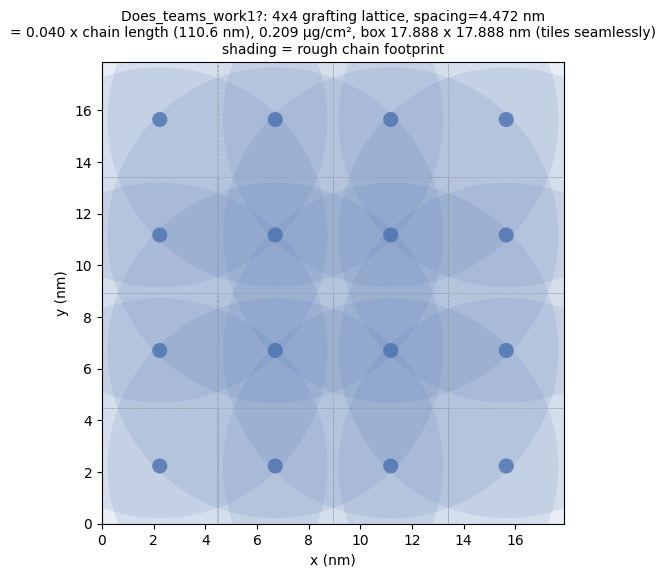

In [5]:
# Pick up edits to tools/ without restarting the kernel — otherwise Python keeps
# the module it imported first, and a function added since then is missing.
# (Written as a call rather than %autoreload so the cell is still plain Python.)
try:
    get_ipython().run_line_magic("load_ext", "autoreload")
    get_ipython().run_line_magic("autoreload", "2")
except NameError:
    pass

import csv

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle

from tools.elibpy import build_sequence_with_features, humanize_seq
from tools.new_simulation import (
    MIN_BOX_L,
    Z_HEIGHT,
    _validate_sequence,
    lattice_positions,
    plan_box,
    plan_steps,
    spacing_for_mass_per_area,
)

# ---- Inputs --------------------------------------------------------------
sim_name = "Does_teams_work1?"                        # simulations/<sim_name>/ — reused by every cell below

USE_ELP_BUILDER = 1  # True: build `sequence` from `components` below via tools.elibpy; False: use the raw string

# Used when USE_ELP_BUILDER = False. Residue 0 becomes the surface anchor ("Z").
sequence = "VPGVGVPGVGVPGVGVPGVGVPGVGVPGVG"     # single-letter AAs

# Used when USE_ELP_BUILDER = True — same (token, label) format as tools.elibpy.build_sequence_with_features:
#   "<letter><count>"  -> that many VPG<letter>G repeats, e.g. "V5" -> VPGVGVPGVGVPGVGVPGVGVPGVG
#   "(FRAGMENT)"        -> literal sequence fragment, inserted as-is
components = [
    ("I4",  "VPGIG"), ("K1", "VPGKG"), ("I6",  "VPGIG"),
    ("(RGD)", "RGD"),
    ("I2",  "VPGIG"), ("M1", "VPGMG"), ("I8",  "VPGIG"),
    ("(RGD)", "RGD"),
    ("K1",  "VPGKG"), ("I9", "VPGIG"), ("K1",  "VPGKG"), ("I1", "VPGIG"),
    ("(RGD)", "RGD"),
    ("I7",  "VPGIG"), ("M1", "VPGMG"), ("I3",  "VPGIG"),
    ("(RGD)", "RGD"),
    ("I5",  "VPGIG"), ("K1", "VPGKG"), ("I5",  "VPGIG"),
]

if USE_ELP_BUILDER:
    built = build_sequence_with_features(components)
    sequence = built["seq"]
    print(f"built sequence:  {humanize_seq(components)}")

# ---- How far apart the chains are grafted --------------------------------
# Three mutually exclusive ways; set exactly one and leave the other two None.
#
#   concentration       same number of *chains* per area: spacing =
#                       1/sqrt(concentration), the same nm whatever the ELP is.
#   spacing_fraction    relative to the chain's *own* length, so the spacing
#                       scales with the ELP: at 0.5 a 300 nm ELP is grafted
#                       150 nm apart and a 600 nm one 300 nm apart.
#   mass_concentration  same *mass* of polymer per area (ug/cm^2, what a QCM-D
#                       or ellipsometry experiment reports). A chain twice as
#                       long weighs twice as much, so it is grafted sqrt(2)
#                       further apart — use this to compare different lengths
#                       at equal surface loading.
concentration = 0.05                             # ELP chains / nm^2, or None
spacing_fraction = None                         # fraction of the chain length, or None
mass_concentration = None                       # ug/cm^2 of grafted polymer, or None
length_measure = "contour"                      # what spacing_fraction is a fraction of:
                                                #   "contour" — fully extended, 0.38 nm/bond
                                                #   "coil"    — random-walk size, 0.38*sqrt(N)

# ---- Empty space around the lattice --------------------------------------
# Bare surface left between the outermost chains and the box wall, as a fraction
# of the spacing, on every side (margin = margin_fraction x spacing).
#   0     default. The lattice tiles the box exactly, so the periodic images
#         continue it without a seam: a rim chain is half a spacing from the
#         wall on one side and half a spacing from the *next* box on the other,
#         i.e. exactly one spacing from its neighbour, as crowded as a chain in
#         the middle. A uniform infinite grafted surface — but chains do reach
#         the boundary and get wrapped to the far side of the trajectory, which
#         looks like them teleporting.
#   0.5   an edge chain starts a full spacing from the wall instead of half of
#         one, which stops most of that wrapping. The cost: neighbours across
#         the boundary are then 2 x spacing apart, so the rim is less crowded
#         than the middle and the run is a finite grafted patch repeated
#         periodically rather than a uniform surface.
#   >0.5  more room still, at the cost of a bigger (slower) box.
# Worth raising for per-chain observables (Rg, height, RMSD), where a dilute rim
# barely matters and a readable trajectory does. Leave at 0 for anything that
# depends on uniform lateral crowding. `spacing` keeps its meaning either way —
# only the box-averaged density is diluted.
margin_fraction = 0

nmol = 16                                       # number of ELP molecules

# ---- Reactive crosslinking (optional) -------------------------------------
# None (default) -> nothing reacts, and the run is bit-for-bit identical to the
# pipeline as it was before this feature existed.
# A number -> the reaction distance in NANOMETRES between two lysine beads (the
# rest of the box maths is in nm too; a post-hoc script that works in angstroms
# is not). Pairs that come closer than this bond permanently *during* the run,
# so a formed crosslink tethers its chains and changes what happens next.
# Read the caveats in tools/crosslink.py before interpreting any of it: the
# sequence and topology of events is meaningful, the rate is not.
crosslink_distance = None       # e.g. 0.8 for 8 A
crosslink_valence = 1           # max bonds per lysine. 1 = bifunctional crosslinker
                                # at 1:1 (glutaraldehyde-like); 2 = trifunctional
                                # junctions (THPP-like), which changes the loop
                                # fraction materially
crosslink_prob = 1.0            # P(react | within cutoff at a check). 1.0 =
                                # diffusion-limited; below that the reaction rate
                                # is decoupled from diffusion (Damkohler sweep)
crosslink_check_every = 1000    # MD steps between reaction checks
crosslink_k = 2000.0            # final bond stiffness, kJ/mol/nm^2
crosslink_r0 = 0.6              # bond equilibrium length, nm
crosslink_ramp_steps = 500      # steps over which k rises 0 -> crosslink_k, so
                                # switching a stiff bond on doesn't spike the
                                # temperature. Resolved over several updates even
                                # when check_every is larger than this.
crosslink_selection = None      # None -> auto-detect lysines (residue name LYS, then K,
                                # then bead name K). Otherwise an explicit list of
                                # bead indices. Either way, residue 0 of each chain
                                # is dropped: that bead is the fixed surface anchor.
crosslink_start_step = 0        # ignore reactions before this step. SET THIS past
                                # equilibration: contacts in the early frames are
                                # artefacts of the initial placement, not
                                # encounters the dynamics produced. The Rg/RMSD
                                # check in the Analyze section says where that is.

# Step counts — the single source of truth used by every cell below (DelftBlue submit
# and local run both read `steps`/`local_steps` from here instead of redefining them).
steps = 7_070_000        # total MD production steps, used by the DelftBlue/GPU submit cell
local_steps = 20_000      # smaller step count for the local CPU/GPU smoke-test cell

# Caps the save interval (steps between saved trajectory frames) that `plan_steps`
# below is allowed to pick — see the "steps -> frames" printout for what this
# actually produces. CALVADOS/create_simulation's own default is 7000; lower it if
# you want more temporal resolution (more saved frames) at a given step count.
max_n_save = 7000
# ---------------------------------------------------------------------------

seq = _validate_sequence(sequence)
plan = plan_box(seq, concentration, nmol, spacing_fraction, length_measure, mass_concentration,
                margin_fraction)

# Per-residue bead diameter (sigma, nm) from the CALVADOS force field.
sigmas: dict[str, float] = {}
with open("residues_CALVADOS2.csv", newline="") as f:
    for row in csv.DictReader(f):
        sigmas[row["one"]] = float(row["sigmas"])
anchor_sigma = sigmas["Z"]  # bead sitting at each anchor point (residue 0 is tagged "Z")

print(f"simulation:      {sim_name}")
print(f"sequence:        {len(seq)} residues, {plan.chain_length:.2f} nm ({length_measure} length), "
      f"{plan.chain_mass_da / 1000:.2f} kDa")
print(f"box:             [{plan.l_box_x}, {plan.l_box_y}, {Z_HEIGHT}] nm")
print(f"lattice:         {plan.nx} x {plan.ny} grafting points, {plan.spacing} nm apart")
if plan.margin:
    print(f"margin:          {plan.margin} nm of empty surface on every side "
          f"({plan.margin_fraction} x the spacing) — chains start that far from the")
    print(f"                 periodic boundary, and neighbours across it are "
          f"{plan.spacing + 2 * plan.margin:.3f} nm apart instead of {plan.spacing} nm, so the")
    print(f"                 rim is a little less crowded than the middle.")
else:
    print(f"margin:          none — the lattice tiles the box exactly, so the periodic images "
          f"continue it seamlessly")
    print(f"                 (infinite surface, every chain equally crowded), but chains reach "
          f"the boundary and wrap.")
print(f"spacing:         {plan.spacing} nm = {plan.achieved_spacing_fraction:.3f} x the chain's "
      f"{plan.chain_length:.2f} nm length"
      + (f" (asked for {spacing_fraction})" if spacing_fraction is not None else ""))
print(f"density:         {plan.achieved_concentration:.5f} chains/nm² on the lattice"
      + (f", {plan.box_concentration:.5f} averaged over the box (the margin dilutes it)"
         if plan.margin else ""))
print(f"surface loading: {plan.achieved_mass_concentration:.4f} µg/cm² "
      f"({plan.achieved_mass_concentration * 10:.3f} mg/m²)"
      + (f" (asked for {mass_concentration})" if mass_concentration is not None else "")
      + (f"; {plan.box_mass_concentration:.4f} µg/cm² over the whole box" if plan.margin else ""))
if plan.clamped:
    if spacing_fraction is not None:
        requested_spacing = spacing_fraction * plan.chain_length
        asked_for = f"{spacing_fraction} x the chain's {plan.chain_length:.2f} nm {length_measure} length"
    elif mass_concentration is not None:
        requested_spacing = spacing_for_mass_per_area(plan.chain_mass_da, mass_concentration)
        asked_for = f"{mass_concentration} µg/cm²"
    else:
        requested_spacing = 1 / concentration ** 0.5
        asked_for = f"{concentration} chains/nm²"
    short_side_cells = min(plan.nx, plan.ny) + 2 * margin_fraction
    print(f"⚠  the requested {asked_for} would make the short side of the box "
          f"{short_side_cells} x {requested_spacing:.3f} = "
          f"{short_side_cells * requested_spacing:.2f} nm (lattice + margin), under the "
          f"{MIN_BOX_L} nm floor "
          f"CALVADOS's cutoffs need — chains were spread to {plan.spacing} nm instead "
          f"({plan.achieved_spacing_fraction:.3f} x the chain length, "
          f"{plan.achieved_mass_concentration:.4f} µg/cm²). Raise nmol to keep the "
          f"spacing you asked for.")
if plan.aspect_ratio > 2.0:
    print(f"⚠  {nmol} molecules only tile as {plan.nx} x {plan.ny} — a very elongated box. "
          f"Pick an nmol with a squarer factorisation.")
if plan.spacing_too_tight:
    print(f"⚠  spacing ({plan.spacing} nm) is tighter than a rough own-size estimate for a "
          f"{len(seq)}-residue chain ({plan.min_sane_spacing:.2f} nm) — chains will start heavily "
          f"overlapped and the simulation is likely to diverge to NaN. Ask for a lower "
          f"concentration / mass loading, or a larger spacing_fraction, and/or fewer chains.")
if plan.spacing < anchor_sigma:
    print(f"⚠  spacing ({plan.spacing} nm) is smaller than a single bead's own diameter "
          f"({anchor_sigma:.3f} nm) — even the anchor beads themselves will overlap.")

if crosslink_distance is not None:
    print(f"crosslinking:    ON — lysine pairs within {crosslink_distance} nm "
          f"({crosslink_distance * 10:.1f} Å) bond during the run; valence "
          f"{crosslink_valence}, p={crosslink_prob},")
    print(f"                 checked every {crosslink_check_every} steps "
          f"({crosslink_check_every * 0.01:.1f} ps), bond k={crosslink_k} kJ/mol/nm² at "
          f"r0={crosslink_r0} nm over {crosslink_ramp_steps} steps")
    if crosslink_start_step:
        print(f"                 reactions ignored before step {crosslink_start_step:,} "
              f"({crosslink_start_step * 0.01 / 1000:.3f} ns)")
    else:
        print("⚠  crosslink_start_step is 0, so contacts left over from the initial placement "
              "count as reactions. Set it past equilibration — the Rg/RMSD check in the "
              "Analyze section says where that is.")
else:
    print("crosslinking:    off (default) — nothing reacts")

# ---- steps -> frames: exactly what create_simulation() will compute internally ----
# CALVADOS's Langevin integrator uses a fixed 0.01 ps (10 fs) timestep per step
# (see calvados/sim.py) — that's not configurable from here, only `steps` is.
DT_PS = 0.01

def _print_step_plan(label: str, n_steps: int) -> None:
    n_save, n_frames, actual_steps = plan_steps(n_steps, max_n_save=max_n_save)
    rounded_note = "" if actual_steps == n_steps else f"  (rounded from {n_steps:,})"
    print(f"\n{label}:")
    print(f"  requested steps: {n_steps:,}")
    print(f"  actual steps:    {actual_steps:,}{rounded_note}")
    print(f"  simulated time:  {actual_steps * DT_PS / 1000:.3f} ns")
    print(f"  save every:      {n_save:,} steps ({n_save * DT_PS:.3f} ps/frame)")
    print(f"  saved frames:    {n_frames:,}  <- this is what len(u.trajectory) will be in the Analyze section")

_print_step_plan("production run ('steps', used by the DelftBlue submit cell)", steps)
_print_step_plan("local smoke test ('local_steps', used by the local run cell)", local_steps)

# ---- 2D preview of the grafting lattice ----
# Same positions the generated prepare.py places molecules at: row-major over
# the nx x ny lattice, each chain at the centre of its own spacing x spacing
# cell, the whole lattice shifted in by the margin. The shaded band is that
# margin — the empty surface a chain has to cross before it reaches the
# periodic boundary and starts wrapping to the far side of the box.
centers = np.array(lattice_positions(nmol, plan.spacing, plan.margin))

fig, ax = plt.subplots(figsize=(6, 6 * plan.l_box_y / plan.l_box_x))
if plan.margin:
    ax.add_patch(plt.Rectangle((0, 0), plan.l_box_x, plan.l_box_y, facecolor="#dd8452",
                               edgecolor="none", alpha=0.10))
    ax.add_patch(plt.Rectangle((plan.margin, plan.margin),
                               plan.l_box_x - 2 * plan.margin, plan.l_box_y - 2 * plan.margin,
                               facecolor="white", edgecolor="#dd8452", linestyle=":",
                               linewidth=0.8))
for x, y in centers:
    ax.add_patch(plt.Rectangle((x - plan.spacing / 2, y - plan.spacing / 2), plan.spacing, plan.spacing,
                               fill=False, edgecolor="#bbbbbb", linestyle="--", linewidth=0.6))
    ax.add_patch(Circle((x, y), radius=plan.min_sane_spacing, facecolor="#4c72b0",
                        edgecolor="none", alpha=0.12))
for x, y in centers:
    ax.add_patch(Circle((x, y), radius=anchor_sigma / 2, facecolor="#4c72b0", edgecolor="none", alpha=0.8))
ax.set_xlim(0, plan.l_box_x)
ax.set_ylim(0, plan.l_box_y)
ax.set_aspect("equal")
ax.set_xlabel("x (nm)")
ax.set_ylabel("y (nm)")
ax.set_title(f"{sim_name}: {plan.nx}x{plan.ny} grafting lattice, spacing={plan.spacing} nm\n"
             f"= {plan.achieved_spacing_fraction:.3f} x chain length ({plan.chain_length:.1f} nm), "
             f"{plan.achieved_mass_concentration:.3f} µg/cm², "
             f"box {plan.l_box_x} x {plan.l_box_y} nm\n"
             + (f"orange rim = {plan.margin} nm margin ({plan.margin_fraction} x spacing); "
                if plan.margin else "no margin — tiles seamlessly; ")
             + "blue shading = rough chain footprint", fontsize=10)
plt.show()

## Prepare + submit to DelftBlue (GPU/SLURM)

Uses `sequence`/`concentration`/`nmol`/`steps`/`max_n_save` from the setup
cell above (see its "steps -> frames" printout for exactly how many frames
this run will save). Generates `simulations/<sim_name>/` (config, FASTA,
`run.py`, `job.sh`) targeting CUDA on DelftBlue's GPU partition.
`SUBMIT_TO_DELFTBLUE` defaults to `False` so nothing is queued until you
explicitly opt in and rerun the cell.

In [6]:
from tools.new_simulation import create_simulation

partition = "gpu-a100"       # SLURM partition
walltime = "0:30:00"        # SLURM walltime (HH:MM:SS)
cpu_per_task = "18"          # SLURM --cpus-per-task

SUBMIT_TO_DELFTBLUE = 1  # set True (and rerun) to actually `sbatch` the job

sim_dir = create_simulation(
    sequence=sequence,
    concentration=concentration,
    spacing_fraction=spacing_fraction,
    mass_concentration=mass_concentration,
    length_measure=length_measure,
    margin_fraction=margin_fraction,
    crosslink_distance=crosslink_distance,
    crosslink_valence=crosslink_valence,
    crosslink_prob=crosslink_prob,
    crosslink_check_every=crosslink_check_every,
    crosslink_k=crosslink_k,
    crosslink_r0=crosslink_r0,
    crosslink_ramp_steps=crosslink_ramp_steps,
    crosslink_start_step=crosslink_start_step,
    crosslink_selection=crosslink_selection,
    nmol=nmol,
    steps=steps,
    name=sim_name,
    platform="CUDA",
    partition=partition,
    walltime=walltime,
    cpu_per_task=cpu_per_task,
    max_n_save=max_n_save,
)

job_script = sim_dir / "runtime" / "job.sh"
print(f"\nruntime/ ready at {sim_dir / 'runtime'}")
print(f"To submit by hand (from a DelftBlue login node):\n  sbatch {job_script}")

if SUBMIT_TO_DELFTBLUE:
    import subprocess

    print(f"\n▶  Submitting to SLURM: {sim_name}")
    subprocess.run(["sbatch", str(job_script)], check=True)

✓  Created simulations/does-teams-work1/prepare.py
   box:        [17.888, 17.888, 50.0] nm
   lattice:    4 x 4 grafting points, 4.472 nm apart, tiling the box exactly (infinite surface via the periodic images)
   chain:      292 residues, 110.58 nm (contour length) — spacing is 0.040 x that
   density:    0.05 chains/nm^2
   mass:       25.14 kDa per chain, 0.2088 ug/cm^2 grafted (2.088 mg/m^2)
⚠  spacing (4.472 nm) is tight for a 292-residue chain (rough own-size estimate: 6.49 nm) — molecules will start heavily overlapped and the simulation is likely to diverge to NaN. Consider a lower concentration / mass loading, a larger spacing fraction, and/or fewer molecules.
   molecules:  16
   platform:   CUDA
   steps:      7070000
▶  Preparing: does-teams-work1
✓  Done — runtime/ folder ready at simulations/does-teams-work1/runtime/
   Next: sim run does-teams-work1   or   sim submit does-teams-work1

runtime/ ready at /home/tnartey/ELP-Simulations/simulations/does-teams-work1/runtime
To

## Prepare + run locally (no sbatch/job.sh)

Uses `local_steps`/`max_n_save` from the setup cell above (see its "local
smoke test" printout for exactly how many frames this run will save).
Generates a separate `simulations/<sim_name>-<platform>/` (so it never
collides with the DelftBlue folder above) and runs it directly in this
notebook — no `sbatch`/`job.sh` involved either way. Set `platform` to
`"CPU"` for a quick sanity check, or `"CUDA"` to run on a GPU directly.

`"CUDA"` only works where a GPU is actually attached to whatever machine/
kernel this notebook is running on: your own workstation if it has an
NVIDIA GPU, or — on DelftBlue — a compute node you're already attached to
interactively (`srun --partition=gpu-a100 --gpus=1 --pty bash` from a login
node, then launch Jupyter from inside that shell). DelftBlue's login nodes
themselves have no GPU, so `platform="CUDA"` will fail there.

In [4]:
import subprocess
import sys
from pathlib import Path

from openmm import Context, Platform, System, VerletIntegrator

from tools.new_simulation import _slugify, create_simulation

platform = "CPU"                 # "CPU" or "CUDA" — see markdown above for where "CUDA" actually works

# create_simulation() slugifies its `name` (e.g. "_" -> "-") when it picks the folder
# name — slugify here too so this cell checks/runs the exact same folder it created,
# even if `sim_name` itself contains characters that get normalized away.
local_sim_name = _slugify(f"{sim_name}-{platform.lower()}")

if platform == "CUDA":
    # Listing platform names isn't enough — OpenMM reports "CUDA" as compiled-in even
    # with no GPU attached (e.g. on a DelftBlue login node). Actually try to open a
    # device so this fails clearly here instead of deep inside create_simulation/run.py.
    try:
        _probe_system = System()
        _probe_system.addParticle(1.0)
        Context(_probe_system, VerletIntegrator(1.0), Platform.getPlatformByName("CUDA"))
    except Exception as e:
        raise RuntimeError(
            "Could not initialize a CUDA device on this kernel — no GPU is attached here "
            "(see the markdown cell above for how to get one on DelftBlue)."
        ) from e

local_sim_dir = Path("simulations") / local_sim_name
if local_sim_dir.exists():
    print(f"↻  simulations/{local_sim_name}/ already exists — reusing it "
          f"(delete the folder, or change sim_name/local_steps, to regenerate).")
else:
    local_sim_dir = create_simulation(
        sequence=sequence,
        concentration=concentration,
        spacing_fraction=spacing_fraction,
        mass_concentration=mass_concentration,
        length_measure=length_measure,
        margin_fraction=margin_fraction,
        crosslink_distance=crosslink_distance,
        crosslink_valence=crosslink_valence,
        crosslink_prob=crosslink_prob,
        crosslink_check_every=crosslink_check_every,
        crosslink_k=crosslink_k,
        crosslink_r0=crosslink_r0,
        crosslink_ramp_steps=crosslink_ramp_steps,
        crosslink_start_step=crosslink_start_step,
        crosslink_selection=crosslink_selection,
        nmol=nmol,
        steps=local_steps,
        name=local_sim_name,
        platform=platform,
        max_n_save=max_n_save,
    )

print(f"▶  Running locally on {platform}: {local_sim_dir.name}")
subprocess.run(
    [sys.executable, "-m", f"simulations.{local_sim_dir.name}.runtime.run"],
    check=True,
)

✓  Created simulations/my-elp-sim-db-2-cpu/prepare.py
   box:        [10.95, 10.95, 50.0] nm
   spacing:    3.161 nm between starting positions
⚠  spacing (3.161 nm) is tight for a 160-residue chain (rough own-size estimate: 4.81 nm) — molecules will start heavily overlapped and the simulation is likely to diverge to NaN. Consider a lower concentration and/or fewer molecules.
   molecules:  12
   platform:   CPU
   steps:      20000
▶  Preparing: my-elp-sim-db-2-cpu
✓  Done — runtime/ folder ready at simulations/my-elp-sim-db-2-cpu/runtime/
   Next: sim run my-elp-sim-db-2-cpu   or   sim submit my-elp-sim-db-2-cpu
▶  Running locally on CPU: my-elp-sim-db-2-cpu
Adding charges for both termini of my-elp-sim-db-2-cpu.
Total number of components in the system: 1
Total number of molecules in the system: 12
Ashbaugh-Hatch potential between particles with lambda=1 and sigma=0.68 at 2.0 nm: -0.0051627815139227455 kJ/mol
Debye-Hückel potential between unit charges at 4.0 nm: 0.00142416032336957

100%|██████████| 10/10 [04:47<00:00, 28.71s/it]


CompletedProcess(args=['/home/tnartey/ELP-Simulations/.venv/bin/python', '-m', 'simulations.my-elp-sim-db-2-cpu.runtime.run'], returncode=0)

# Analyze results

The cells below load a finished trajectory (`sim_name` here is independent of
the setup section above — point it at whichever simulation you want to
inspect).

In [7]:
# Pick up edits to tools/ without restarting the kernel — otherwise Python keeps
# the module it imported first, and a function added since then is missing.
# (Written as a call rather than %autoreload so the cell is still plain Python.)
try:
    get_ipython().run_line_magic("load_ext", "autoreload")
    get_ipython().run_line_magic("autoreload", "2")
except NameError:
    pass

import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt

sim_name = "Does_teams_work1"

path_top = f"simulations/{sim_name}/runtime/top.pdb"
path_tra = f"simulations/{sim_name}/runtime/{sim_name}.dcd"
u = mda.Universe(path_top, path_tra)

# Everything below is derived from the topology/trajectory themselves, so the
# rest of this notebook adapts to whatever PDB it's pointed at (chain count,
# chain length, box size, which end is anchored) instead of assuming the
# shape of one specific simulation.
chains = u.segments
n_chains = len(chains)

chain_lengths = {len(seg.residues) for seg in chains}
if len(chain_lengths) != 1:
    raise ValueError(f"Chains have differing lengths: {sorted(chain_lengths)}")
n_res_per_chain = chain_lengths.pop()

box = u.dimensions[:3].copy()  # [x, y, z] in Angstrom, read from the PDB's CRYST1 record

print(f"{n_chains} chains x {n_res_per_chain} residues/chain, box = {box}")

def unwrap_in_time(positions):
    """Undo periodic-boundary wrapping so x/y traces are continuous in time.

    The chains are grafted to an infinite surface represented by the periodic
    images, so a molecule that leans across the box edge is written to the
    trajectory translated by exactly one box length — which shows up in a plot
    as the molecule teleporting across the box. The jump is a whole-molecule
    rigid translation, so it can be removed exactly: any frame-to-frame step
    bigger than half a box is a wrap, not motion.

    Note this is only needed for *plotting* coordinates. Distances computed with
    the minimum-image convention (as the crosslinking cells below do) are
    already correct on the wrapped coordinates and must not be unwrapped.
    """
    positions = np.asarray(positions, dtype=float).copy()
    step = np.diff(positions[..., :2], axis=0)
    wraps = np.round(step / box[:2])
    positions[1:, ..., :2] -= np.cumsum(wraps, axis=0) * box[:2]
    return positions

def get_pos_of_residue(chain_idx, res_idx, unwrap=True):
    """CA position of residue `res_idx` (within-chain) of chain `chain_idx`, across all frames."""
    atom = chains[chain_idx].residues[res_idx].atoms.select_atoms("name CA")
    positions = np.empty((len(u.trajectory), 3))
    for i, ts in enumerate(u.trajectory):
        positions[i] = atom.positions[0]
    return unwrap_in_time(positions) if unwrap else positions

def track_atoms(atomgroup, unwrap=False):
    """Positions of every atom in `atomgroup`, across all frames: shape (n_frames, n_atoms, 3).

    `unwrap` defaults to False here because the callers below use this for z
    (never wrapped in practice — the wall keeps every bead well inside the
    50 nm z box) and for minimum-image distances, neither of which wants it.
    """
    positions = np.empty((len(u.trajectory), len(atomgroup), 3))
    for i, ts in enumerate(u.trajectory):
        positions[i] = atomgroup.positions
    return unwrap_in_time(positions) if unwrap else positions

# Which chain end sits near the surface (small z) vs. dangles freely: found
# from the trajectory itself rather than assumed, so it stays correct whether
# the anchor tag was built onto residue 0 or residue -1 of the sequence.
probe_chains = range(0, n_chains, max(1, n_chains // 5))
empty = u.atoms[:0]
first_end = sum((chains[c].residues[0].atoms.select_atoms("name CA") for c in probe_chains), empty)
last_end = sum((chains[c].residues[-1].atoms.select_atoms("name CA") for c in probe_chains), empty)
mean_z_first = track_atoms(first_end)[..., 2].mean()
mean_z_last = track_atoms(last_end)[..., 2].mean()
anchor_idx, free_idx = (0, -1) if mean_z_first < mean_z_last else (-1, 0)

print(f"anchored end: residue index {anchor_idx} (mean z={min(mean_z_first, mean_z_last):.1f} Å); "
      f"free end: residue index {free_idx} (mean z={max(mean_z_first, mean_z_last):.1f} Å)")

# The anchor bead is tagged "Z", which CALVADOS gives MW -2; the +2 N-terminus
# patch cancels that to exactly 0, and OpenMM holds zero-mass particles fixed.
# So every chain is rigidly grafted and its anchor cannot move at all — any
# apparent movement of one is periodic wrapping, and this counts how much of
# that the trajectory contains.
anchor_all = sum((chains[c].residues[anchor_idx].atoms.select_atoms("name CA")
                  for c in range(n_chains)), empty)
anchor_raw = track_atoms(anchor_all)
n_wraps = int(np.count_nonzero(np.abs(np.diff(anchor_raw[..., :2], axis=0)) > box[:2] / 2))
residual = np.abs(unwrap_in_time(anchor_raw) - unwrap_in_time(anchor_raw)[0]).max()
print(f"periodic wrapping: {n_wraps} whole-molecule wrap events in this trajectory "
      f"(anchor movement after unwrapping: {residual:.4f} Å — grafted anchors cannot move)")


# ---- Saving results ------------------------------------------------------
# runtime/ lives on /scratch, is gitignored, and `sim clean` deletes it, so a
# plot written there vanishes with the run and never reaches GitHub. These
# helpers file a copy in simulations/<sim_name>/results/ instead — beside
# prepare.py, and tracked. See tools/results.py.
import io
import sys

from tools.results import save_figure, save_text


def save_fig(name, fig=None):
    """Save the current (or given) figure into this simulation's results/ folder."""
    save_figure(sim_name, name, fig if fig is not None else plt.gcf())
    print(f"saved \u2192 simulations/{sim_name}/results/{name}")


class _Tee:
    """A stdout that still writes to the notebook while recording what it wrote."""

    def __init__(self, stream):
        self.stream = stream
        self.buffer = io.StringIO()

    def write(self, text):
        self.stream.write(text)
        self.buffer.write(text)
        return len(text)

    def flush(self):
        self.stream.flush()


def capture_start():
    """Begin recording print() output. Cell output is unaffected — this only tees."""
    if not isinstance(sys.stdout, _Tee):
        sys.stdout = _Tee(sys.stdout)


def capture_save(name):
    """Stop recording and write everything printed since capture_start() to results/<name>."""
    if not isinstance(sys.stdout, _Tee):
        return
    tee, sys.stdout = sys.stdout, sys.stdout.stream
    save_text(sim_name, name, tee.buffer.getvalue())
    print(f"saved \u2192 simulations/{sim_name}/results/{name}")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


/home/tnartey/ELP-Simulations/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


FileNotFoundError: [Errno 2] No such file or directory: 'simulations/Does_teams_work1/runtime/top.pdb'

## Has it equilibrated? (radius of gyration and RMSD)

Run this first on any finished trajectory. It measures two things about the
grafted chains, frame by frame, and shows each of them two ways — **per frame**
(the raw relaxation and its noise) and **cumulative** (the running mean, plus
the reverse cumulative mean, which is flat exactly from the point equilibrium
is reached):

* **Rg**, the size of a chain — how far the coil has collapsed out of its
  extended starting conformation;
* **RMSD** from the first saved frame, measured about each chain's own grafting
  point — how much memory of the starting conformation is left.

They fail differently, which is why both are here: a chain reaches its final
size long before it has forgotten the shape it started in, so the run counts as
equilibrated only once *both* have plateaued, and it is only as well sampled as
the slower of the two.

From that it reports:

* **when** the run equilibrated — the burn-in to discard, chosen by maximising
  the number of independent samples left (Chodera's method),
* **how many independent samples** the rest is worth, given the autocorrelation
  time of each observable — i.e. whether the average is actually supported by
  the data,
* **how long the next run of a comparable sequence needs to be**, which is the
  point of the exercise when screening many sequences.

It leaves `production_start_frame` behind, so the cells below can be restricted
to equilibrated frames with `[production_start_frame:]`.

Time axes come from `runtime/metadata.csv`; if a run predates it, generate it
with `uv run sim metadata <sim_name>` (or `--all`).

simulation:        does-db-work-2
trajectory:        1010 frames, 12 chains x 160 residues, 70.70 ns total
equilibration:     discard the first 41 frames (2.87 ns) = 4% of the run
correlation time:  g = 15.3 frames (1.07 ns) per independent sample
usable samples:    N_eff = 63 independent samples in the remaining 969 frames
equilibrium Rg:    4.122 +/- 0.030 nm  (per-chain spread 0.898 nm)
residual drift:    1.5 sigma between the two halves of the production window

✓  equilibrated after 2.87 ns, with 63 independent samples to average over.

next run of this sequence: ~11,008,000 steps (110.07 ns) for N_eff = 100 — longer than the 7,070,000 steps this run used.
   (burn-in 2.87 ns + 100 x 1.07 ns; longer chains and tighter spacings relax more slowly, so re-check per sequence.)


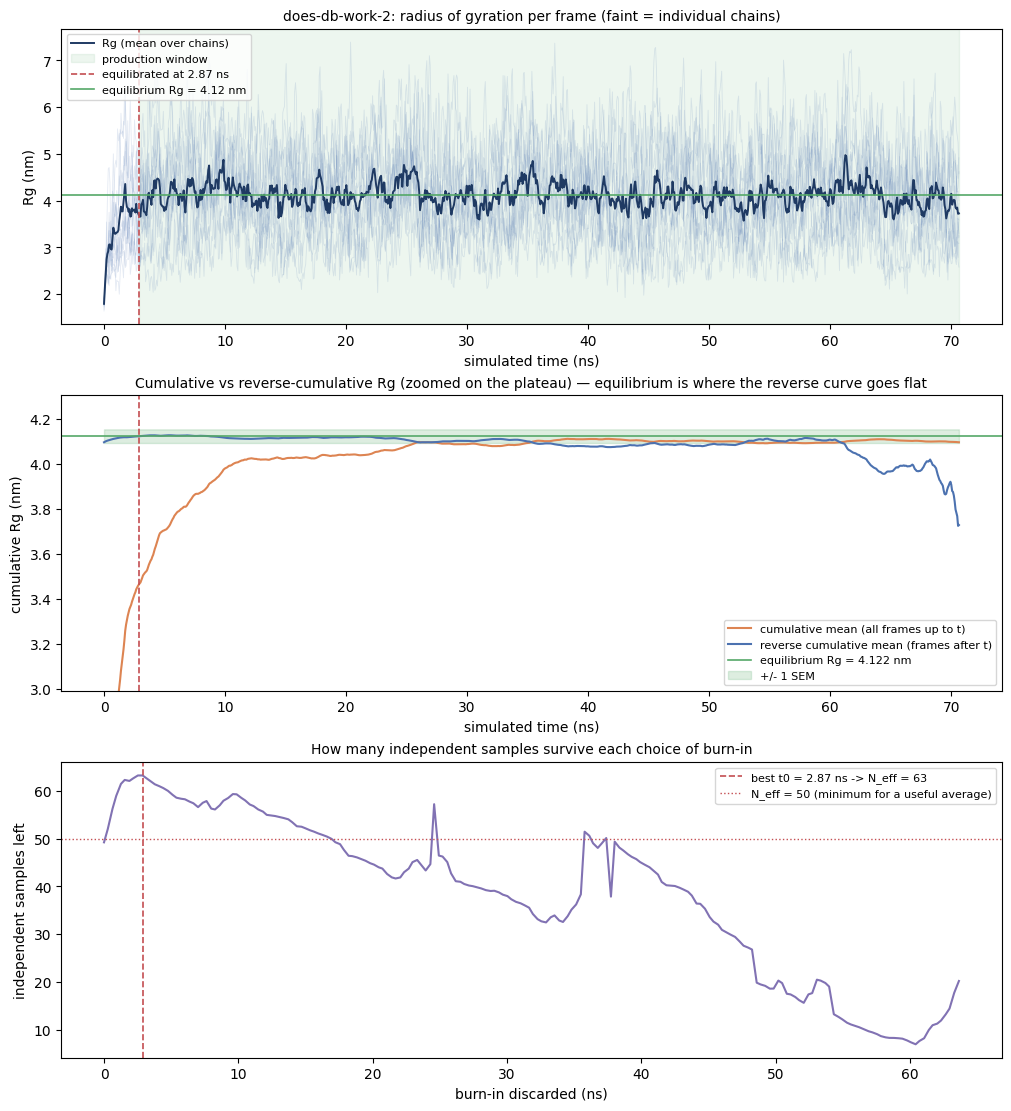

In [4]:
capture_start()

# ---- Equilibration check: radius of gyration and RMSD over time -----------
# "Has this run settled down, and how much of it is actually usable?" — so the
# next sequence can be given the shortest run that still gives good statistics
# instead of a guessed step count.
#
# Two observables, because they fail differently: Rg is the *size* of a chain
# and says nothing about whether it is still exploring, while RMSD from the
# starting conformation is pure memory of where it began. A collapsed chain
# reaches its final Rg long before it has forgotten its initial shape, so the
# run is equilibrated only once both have plateaued.
#
# Each is shown two ways:
#   normal      the value per frame, averaged over the grafted chains. Shows
#               the relaxation out of the starting conformation and the noise.
#   cumulative  the running mean: still drifting while the run is relaxing,
#               flat once the average has stopped moving. Its mirror image, the
#               *reverse* cumulative mean (mean of everything after t), is the
#               sharper test — it is flat from the frame equilibrium is reached,
#               whereas the forward one drags the burn-in along forever.
#
# The equilibration frame itself is picked the standard way (Chodera, JCTC
# 2016): discard t0 frames, and choose the t0 that leaves the most *independent*
# samples, N_eff = (N - t0) / g, where g is the statistical inefficiency
# (1 + 2 x integrated autocorrelation) of what remains. Throwing away too
# little leaves biased burn-in in the average; throwing away too much leaves
# too few samples. The maximum of N_eff(t0) is the trade-off point.

import numpy as np
import matplotlib.pyplot as plt

from tools.metadata import as_float, read_metadata

MIN_EFFECTIVE_SAMPLES = 50      # below this the production window is too short to average over
TARGET_EFFECTIVE_SAMPLES = 100  # what the "how long should the next run be" estimate aims for


def chain_observables(universe, segments, box_dims):
    """Per-chain Rg and RMSD for every frame — two (n_frames, n_chains) arrays, in nm.

    Three things this has to get right:

    * Periodic images. A chain leaning over the box edge is written to the DCD
      wrapped, and a naive Rg on those coordinates is nonsense. Bonds are ~0.38
      nm and the box is tens of nm, so walking along the backbone and taking the
      minimum image of every bond vector rebuilds the chain exactly, whether the
      trajectory wrapped it as a whole or split it.
    * Whole-molecule wrapping, for the RMSD specifically. A chain that leans
      across the boundary is written translated by a whole box vector, which
      would swamp any RMSD to an earlier frame. Coordinates are therefore taken
      relative to the chain's own anchor bead, which is grafted and cannot move
      — so the relative coordinates are wrap-free, and the RMSD measures purely
      how far the chain has moved from the conformation it started in.
    * Mass weighting. The anchor bead is tagged "Z" and carries mass 0 (that is
      what pins it), so a mass-weighted Rg would silently drop the one bead that
      defines the grafting point. These are the geometric quantities — every
      bead counts once.

    No rotational superposition is done: the surface and the fixed anchor give
    the chain a real frame of reference, so swinging around the grafting point
    is genuine motion to be sampled, not a nuisance degree of freedom to fit
    away. The RMSD reference is the first *saved* frame.
    """
    index = np.array([seg.atoms.indices for seg in segments])  # (n_chains, n_beads)
    n_frames = len(universe.trajectory)
    rg = np.empty((n_frames, len(segments)))
    rmsd = np.empty((n_frames, len(segments)))
    reference = None

    for i, _ts in enumerate(universe.trajectory):
        pos = universe.atoms.positions[index]              # (n_chains, n_beads, 3), Angstrom
        bond = np.diff(pos, axis=1)
        bond -= np.round(bond / box_dims) * box_dims       # minimum image, bond by bond
        whole = np.concatenate(
            [pos[:, :1], pos[:, :1] + np.cumsum(bond, axis=1)], axis=1
        )
        anchored = whole - whole[:, :1]                    # relative to the grafted bead

        dev = anchored - anchored.mean(axis=1, keepdims=True)
        rg[i] = np.sqrt((dev ** 2).sum(axis=2).mean(axis=1))

        if reference is None:
            reference = anchored.copy()
        rmsd[i] = np.sqrt(((anchored - reference) ** 2).sum(axis=2).mean(axis=1))

    return rg / 10.0, rmsd / 10.0  # Angstrom -> nm


def statistical_inefficiency(series):
    """g = 1 + 2 * sum_t (1 - t/N) C(t), truncated at the first non-positive C(t).

    g is how many frames one independent sample is worth: N frames of a
    correlated series carry only N/g of the information of N independent ones.
    """
    x = np.asarray(series, dtype=float)
    n = len(x)
    if n < 3:
        return 1.0
    dx = x - x.mean()
    var = dx.dot(dx) / n
    if var <= 0:
        return 1.0
    g = 1.0
    for lag in range(1, n - 1):
        c = dx[:-lag].dot(dx[lag:]) / ((n - lag) * var)
        if c <= 0 and lag > 1:
            break
        g += 2.0 * c * (1.0 - lag / n)
    return max(1.0, g)


def detect_equilibration(series, n_candidates=200):
    """(t0, g, n_eff, candidates, n_eff_curve) — burn-in length maximising independent samples."""
    n = len(series)
    if n < 10:
        return 0, 1.0, float(n), np.array([0]), np.array([float(n)])
    candidates = np.unique(np.linspace(0, int(0.9 * n), min(n_candidates, n)).astype(int))
    n_eff_curve = np.array([(n - t0) / statistical_inefficiency(series[t0:]) for t0 in candidates])
    best = int(candidates[int(np.argmax(n_eff_curve))])
    g = statistical_inefficiency(series[best:])
    return best, g, (n - best) / g, candidates, n_eff_curve


def analyse(series):
    """Everything the plots and the printout need about one observable's time series."""
    n = len(series)
    t0, g, n_eff, candidates, n_eff_curve = detect_equilibration(series)
    production = series[t0:]
    mean = production.mean()
    sem = production.std(ddof=1) / np.sqrt(max(n_eff, 1.0))  # error on *independent* samples
    half = len(production) // 2
    drift = (abs(production[:half].mean() - production[half:].mean()) / (sem * np.sqrt(2))
             if half and sem > 0 else 0.0)
    return {
        "series": series,
        "t0": t0, "g": g, "n_eff": n_eff, "mean": mean, "sem": sem, "drift": drift,
        "candidates": candidates, "n_eff_curve": n_eff_curve,
        "cumulative": np.cumsum(series) / np.arange(1, n + 1),
        "reverse_cumulative": (np.cumsum(series[::-1]) / np.arange(1, n + 1))[::-1],
    }


# ---- time axis: real simulated time when metadata.csv is there, frames otherwise ----
meta = read_metadata(f"simulations/{sim_name}/runtime")
ns_per_frame = as_float(meta, "time_per_frame_ps", default=np.nan) / 1000.0
if not np.isfinite(ns_per_frame) or ns_per_frame <= 0:
    ns_per_frame = np.nan
    print("!  no runtime/metadata.csv for this run — showing frames instead of ns "
          f"(run 'uv run sim metadata {sim_name}' to generate it).")

rg_per_chain, rmsd_per_chain = chain_observables(u, chains, box)
per_chain = {"Rg": rg_per_chain, "RMSD": rmsd_per_chain}
results = {name: analyse(values.mean(axis=1)) for name, values in per_chain.items()}
n_frames = len(rg_per_chain)

# Smoke tests are a fraction of a nanosecond and production runs are tens of
# them, so the time unit follows the run rather than being fixed at ns.
use_time = np.isfinite(ns_per_frame)
if not use_time:
    time_unit, unit_per_frame = "frames", 1.0
elif n_frames * ns_per_frame >= 1.0:
    time_unit, unit_per_frame = "ns", ns_per_frame
else:
    time_unit, unit_per_frame = "ps", ns_per_frame * 1000.0

x = np.arange(n_frames) * unit_per_frame
xlabel = f"simulated time ({time_unit})" if use_time else "frame"


def fmt_t(frames):
    """A duration given in frames, printed in whatever unit suits this run."""
    return f"{frames * unit_per_frame:.2f} {time_unit}" if use_time else f"frame {frames:.0f}"


# The run is only equilibrated once *both* observables are, and it is only as
# well sampled as its slowest mode — so the recommendation takes the worst case.
t0 = max(r["t0"] for r in results.values())
g_slowest = max(r["g"] for r in results.values())
n_eff_worst = min(r["n_eff"] for r in results.values())
drift_worst = max(r["drift"] for r in results.values())

print(f"simulation:        {sim_name}")
print(f"trajectory:        {n_frames} frames, {n_chains} chains x {n_res_per_chain} residues"
      + (f", {fmt_t(n_frames)} total" if use_time else ""))
print()
print(f"{'':<6} {'equilibrated after':>20} {'correlation time':>18} {'N_eff':>7} "
      f"{'plateau (nm)':>18} {'drift':>8}")
for name, r in results.items():
    plateau = f"{r['mean']:.3f} +/- {r['sem']:.3f}"
    print(f"{name:<6} {fmt_t(r['t0']):>20} {fmt_t(r['g']):>18} {r['n_eff']:>7.0f} "
          f"{plateau:>18} {r['drift']:>7.1f}σ")
print(f"\nburn-in to discard: {t0} frames ({fmt_t(t0)}) = {100 * t0 / n_frames:.0f}% of the run "
      f"— the later of the two")

if t0 >= 0.9 * n_frames - 1:
    print("\n⚠  NOT EQUILIBRATED — still moving at the end of the trajectory. Nothing here is safe "
          "to average; this run needs to be longer.")
elif n_eff_worst < MIN_EFFECTIVE_SAMPLES:
    print(f"\n⚠  equilibrated, but only {n_eff_worst:.0f} independent samples of the slowest "
          f"observable — averages are usable with caution and error bars will be wide.")
elif drift_worst > 2:
    print(f"\n⚠  {drift_worst:.1f}σ of drift remains after the cut — a slow mode is still relaxing. "
          f"Treat the plateau values as provisional.")
else:
    print(f"\n✓  equilibrated after {fmt_t(t0)}, with {n_eff_worst:.0f} independent samples to "
          f"average over.")

# How long the *next* run of a sequence like this needs to be: the burn-in it
# takes to equilibrate, plus enough correlation times to average properly.
needed_frames = t0 + TARGET_EFFECTIVE_SAMPLES * g_slowest
steps_per_frame = as_float(meta, "steps_per_frame", default=np.nan)
total_steps = as_float(meta, "total_steps", default=np.nan)
if np.isfinite(steps_per_frame):
    needed_steps = int(np.ceil(needed_frames * steps_per_frame / 1000) * 1000)
    verdict = "shorter" if needed_steps < total_steps else "longer"
    print(f"\nnext run of this sequence: ~{needed_steps:,} steps ({fmt_t(needed_frames)}) for "
          f"N_eff = {TARGET_EFFECTIVE_SAMPLES} — {verdict} than the {int(total_steps):,} steps "
          f"this run used.")
    print(f"   (burn-in {fmt_t(t0)} + {TARGET_EFFECTIVE_SAMPLES} x {fmt_t(g_slowest)}; longer "
          f"chains and tighter spacings relax more slowly, so re-check per sequence.)")

# Frames the rest of the notebook should average over. Slice any per-frame
# array below with [production_start_frame:] to drop the burn-in.
production_start_frame = t0

# ---- plots: one column per observable -------------------------------------
fig, axes = plt.subplots(3, 2, figsize=(14, 11), constrained_layout=True)

for col, (name, r) in enumerate(results.items()):
    values = per_chain[name]
    unit = f"{name} (nm)"

    ax = axes[0, col]
    for c in range(values.shape[1]):
        ax.plot(x, values[:, c], color="#4c72b0", alpha=0.15, linewidth=0.6)
    ax.plot(x, r["series"], color="#1f3a63", linewidth=1.4, label=f"{name} (mean over chains)")
    ax.axvspan(x[r["t0"]], x[-1], color="#55a868", alpha=0.10, label="production window")
    ax.axvline(x[r["t0"]], color="#c44e52", linestyle="--", linewidth=1.2,
               label=f"equilibrated at {fmt_t(r['t0'])}")
    ax.axhline(r["mean"], color="#55a868", linewidth=1.2, label=f"plateau = {r['mean']:.2f} nm")
    ax.set_ylabel(unit)
    ax.set_xlabel(xlabel)
    ax.set_title(f"{name} per frame — {sim_name}\n(faint = individual chains)", fontsize=10)
    ax.legend(fontsize=8, loc="best")

    ax = axes[1, col]
    ax.plot(x, r["cumulative"], color="#dd8452", linewidth=1.5,
            label="cumulative mean (all frames up to t)")
    ax.plot(x, r["reverse_cumulative"], color="#4c72b0", linewidth=1.5,
            label="reverse cumulative mean (frames after t)")
    ax.axhline(r["mean"], color="#55a868", linewidth=1.2, label=f"plateau = {r['mean']:.3f} nm")
    ax.fill_between(x, r["mean"] - r["sem"], r["mean"] + r["sem"], color="#55a868", alpha=0.20,
                    label="+/- 1 SEM")
    ax.axvline(x[r["t0"]], color="#c44e52", linestyle="--", linewidth=1.2)
    # The first few frames of the cumulative mean carry the whole starting-structure
    # transient and would squash the plateau — the interesting part — into a line.
    tail = slice(max(1, n_frames // 50), None)
    lo = min(r["cumulative"][tail].min(), r["reverse_cumulative"][tail].min(), r["mean"] - 3 * r["sem"])
    hi = max(r["cumulative"][tail].max(), r["reverse_cumulative"][tail].max(), r["mean"] + 3 * r["sem"])
    pad = 0.08 * (hi - lo) or 0.02 * max(r["mean"], 1e-9)
    ax.set_ylim(lo - pad, hi + pad)
    ax.set_ylabel(f"cumulative {unit}")
    ax.set_xlabel(xlabel)
    ax.set_title(f"{name}: cumulative vs reverse-cumulative (zoomed on the plateau)\n"
                 f"equilibrium is where the reverse curve goes flat", fontsize=10)
    ax.legend(fontsize=8, loc="best")

    ax = axes[2, col]
    ax.plot(r["candidates"] * unit_per_frame, r["n_eff_curve"], color="#8172b3", linewidth=1.5)
    ax.axvline(x[r["t0"]], color="#c44e52", linestyle="--", linewidth=1.2,
               label=f"best t0 = {fmt_t(r['t0'])} -> N_eff = {r['n_eff']:.0f}")
    ax.axhline(MIN_EFFECTIVE_SAMPLES, color="#c44e52", linestyle=":", linewidth=1.0,
               label=f"N_eff = {MIN_EFFECTIVE_SAMPLES} (minimum for a useful average)")
    ax.set_xlabel(f"burn-in discarded ({time_unit})")
    ax.set_ylabel("independent samples left")
    ax.set_title(f"{name}: independent samples surviving each choice of burn-in", fontsize=10)
    ax.legend(fontsize=8, loc="best")

save_fig("equilibration_rg_rmsd.png")
plt.show()
capture_save("equilibration_rg_rmsd.txt")


## Amino acid distribution along z

Pick a single-letter amino acid code (`aa_letter`, matching the `one` column
of `residues_CALVADOS2.csv`) and see how that residue type is distributed
across the z-height, pooled over every chain and every saved frame from
`start_frame` onward (raise `start_frame` to drop early/equilibration
frames from the histogram).

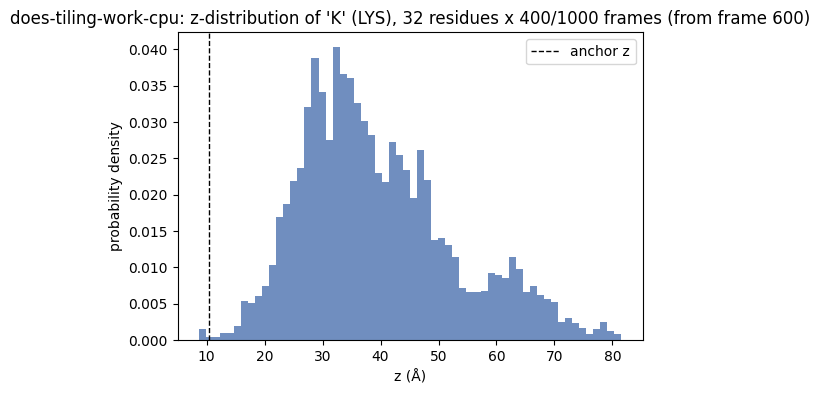

In [2]:
import csv

import numpy as np
import matplotlib.pyplot as plt

aa_letter = "K"    # single-letter amino acid code to inspect (see residues_CALVADOS2.csv "one" column)
start_frame = 600    # first saved frame to include (0-based) — raise this to skip equilibration frames

# one-letter -> three-letter resname, from the same CALVADOS residue table used to build the topology
one_to_three = {}
with open("residues_CALVADOS2.csv", newline="") as f:
    for row in csv.DictReader(f):
        one_to_three[row["one"]] = row["three"]
if aa_letter not in one_to_three:
    raise ValueError(f"Unknown amino acid letter {aa_letter!r} — see residues_CALVADOS2.csv")
target_resname = one_to_three[aa_letter]

# The surface anchor (residue anchor_idx of every chain) is always relabelled "Z" in the
# topology regardless of the original sequence letter, and "Z" reuses valine's
# resname/sigma — exclude those beads so a query for "V" isn't contaminated by the
# (wall-constrained) anchors.
anchor_ca = sum(
    (chains[c].residues[anchor_idx].atoms.select_atoms("name CA") for c in range(n_chains)),
    empty,
)
target_ca = u.select_atoms(f"name CA and resname {target_resname}") - anchor_ca

if len(target_ca) == 0:
    # sim_name here is independent of any sequence built earlier in the notebook —
    # this trajectory simply may never have contained an '{aa_letter}'. Show what it
    # actually does contain so that's obvious instead of a guessing game.
    present = sorted({res.resname for res in chains[0].residues})
    raise ValueError(
        f"No non-anchor '{aa_letter}' ({target_resname}) residues found in trajectory "
        f"'{sim_name}'. Residue types actually present in this trajectory: {present}. "
        f"(sim_name in this Analyze section is independent of any sequence set up above — "
        f"make sure you prepared/ran a simulation whose sequence contains '{aa_letter}', "
        f"then point sim_name at that simulation's folder.)"
    )

if not (0 <= start_frame < len(u.trajectory)):
    raise ValueError(f"start_frame={start_frame} is out of range for {len(u.trajectory)} frames.")

z_all_full = track_atoms(target_ca)[..., 2]  # shape (n_frames, n_target_atoms), every saved frame
z_all = z_all_full[start_frame:]             # frames >= start_frame; also used by the cumulative-average cell below
anchor_z = min(mean_z_first, mean_z_last)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(z_all.ravel(), bins=60, density=True, color="#4c72b0", alpha=0.8)
ax.axvline(anchor_z, color="black", linestyle="--", linewidth=1, label="anchor z")
ax.set_xlabel("z (Å)")
ax.set_ylabel("probability density")
ax.set_title(f"{sim_name}: z-distribution of '{aa_letter}' ({target_resname}), "
             f"{target_ca.n_atoms} residues x {z_all.shape[0]}/{z_all_full.shape[0]} frames "
             f"(from frame {start_frame})")
ax.legend()
save_fig("z_distribution.png")
plt.show()


## Cumulative average distribution over time (equilibration check)

Uses `z_all` from the cell above (i.e. already restricted to frames >=
`start_frame` — frame indices below are relative to that offset). Shows the
z-distribution of `aa_letter` built from only the first `t` frames, for
growing `t`, plus how far that cumulative-average distribution still is from
the full-trajectory one (total-variation distance). Once the distance
settles near zero, adding more frames no longer changes the distribution —
i.e. the simulation has become stable for this residue.

'K' z-distribution looks stable (TV distance <= 0.05) from frame 325/400 onward.


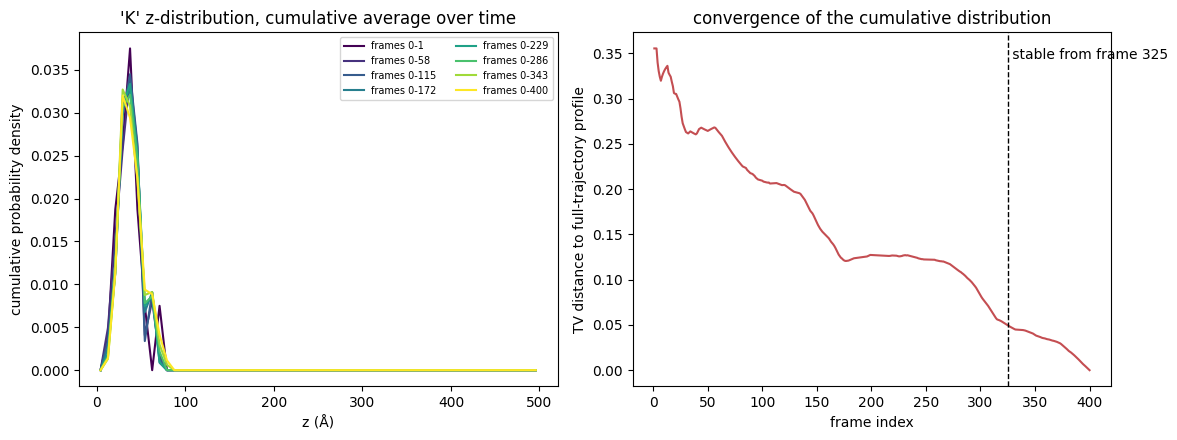

In [3]:
capture_start()

n_frames_total, n_target_atoms = z_all.shape

n_bins = 60
bins = np.linspace(0, box[2], n_bins + 1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
bin_width = bins[1] - bins[0]

# Per-frame counts, then cumulative over frames -> a density profile built from
# only frames [0, t] for every t, each normalized to integrate to 1 on its own.
per_frame_counts = np.array(
    [np.histogram(z_all[t], bins=bins)[0] for t in range(n_frames_total)], dtype=float
)
cum_counts = np.cumsum(per_frame_counts, axis=0)
cum_density = cum_counts / (cum_counts.sum(axis=1, keepdims=True) * bin_width)
final_density = cum_density[-1]  # profile from the whole trajectory

# Total-variation distance between the cumulative profile up to frame t and the
# full-trajectory profile: how much the "average so far" still has left to move.
drift = np.abs(cum_density - final_density).sum(axis=1) * bin_width

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
checkpoints = np.unique(np.linspace(0, n_frames_total - 1, min(8, n_frames_total), dtype=int))
cmap = plt.get_cmap("viridis")
for i, t in enumerate(checkpoints):
    ax.plot(bin_centers, cum_density[t], color=cmap(i / max(1, len(checkpoints) - 1)),
            label=f"frames 0-{t + 1}")
ax.set_xlabel("z (\u00c5)")
ax.set_ylabel("cumulative probability density")
ax.set_title(f"'{aa_letter}' z-distribution, cumulative average over time")
ax.legend(fontsize=7, ncol=2)

ax = axes[1]
ax.plot(np.arange(1, n_frames_total + 1), drift, color="#c44e52")
ax.set_xlabel("frame index")
ax.set_ylabel("TV distance to full-trajectory profile")
ax.set_title("convergence of the cumulative distribution")

# Heuristic "stable after" point: the first frame beyond which drift never
# exceeds `tol` again (tail-anchored, so an early lucky dip isn't flagged).
tol = 0.05
above_tol = np.nonzero(drift > tol)[0]  # 0-indexed frames still above tolerance
if above_tol.size == 0:
    stable_frame = 1
elif above_tol[-1] == n_frames_total - 1:
    stable_frame = None
else:
    stable_frame = above_tol[-1] + 2  # 1-indexed frame right after the last violation

if stable_frame is not None:
    ax.axvline(stable_frame, color="black", linestyle="--", linewidth=1)
    ax.text(stable_frame, drift.max(), f" stable from frame {stable_frame}", va="top")
    print(f"'{aa_letter}' z-distribution looks stable (TV distance <= {tol}) from frame "
          f"{stable_frame}/{n_frames_total} onward.")
else:
    print(f"'{aa_letter}' z-distribution never settles within TV distance {tol} of the "
          f"full-trajectory profile \u2014 try a looser tol, more sampling, or check for a slow drift.")

fig.tight_layout()
save_fig("z_distribution_convergence.png")
plt.show()
capture_save("z_distribution_convergence.txt")


## Free-end 3D trajectories

The path traced by the free end (residue index `free_idx` — the end
*opposite* the surface anchor) of a sample of `max_chains_3d` chains, across
every saved frame — one colored line per chain. Axes are box coordinates in
Å, scaled to the actual simulation box (`box[0] x box[1] x box[2]`) so you
can see how much of the box each chain's free end actually explores, and
whether that exploration stays close to the surface (small z, near the
dashed anchor level used in later cells) or wanders throughout the box.

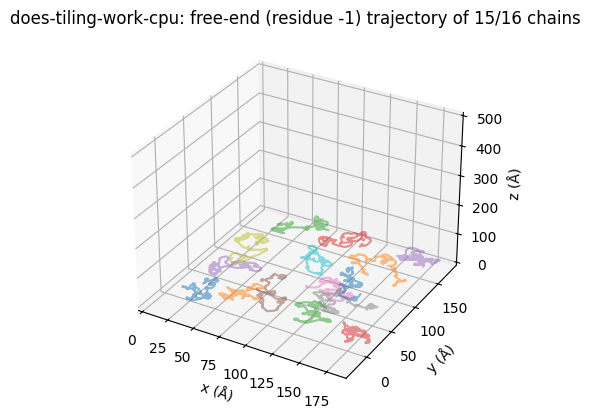

In [5]:
fig = plt.figure()
ax = plt.axes(projection='3d')

max_chains_3d = 15
sample_chain_idx = np.linspace(0, n_chains - 1, min(max_chains_3d, n_chains), dtype=int)

trajectories = []
for c in sample_chain_idx:
    positions = get_pos_of_residue(c, free_idx)
    trajectories.append(positions)

    ax.plot3D(positions[:, 0], positions[:, 1], positions[:, 2], alpha=.5)

# Coordinates are unwrapped (see unwrap_in_time), so a chain leaning across the
# box edge continues smoothly past it instead of teleporting back — which means
# x/y can legitimately fall outside [0, box]. Widen the limits to whatever the
# traces actually cover, keeping the box itself in view for reference.
xy = np.concatenate(trajectories)[:, :2]
ax.axes.set_xlim3d([min(0, xy[:, 0].min()), max(box[0], xy[:, 0].max())])
ax.axes.set_ylim3d([min(0, xy[:, 1].min()), max(box[1], xy[:, 1].max())])
ax.axes.set_zlim3d([0, box[2]])
ax.set_xlabel("x (Å)")
ax.set_ylabel("y (Å)")
ax.set_zlabel("z (Å)")
ax.set_title(f"{sim_name}: free-end (residue {free_idx}) trajectory of {len(sample_chain_idx)}/{n_chains} chains")
save_fig("free_end_trajectories_3d.png")
plt.show()


## Free-end x/y/z coordinates over time, per chain

Same sample of chains as the 3D plot above, but split into individual x, y,
and z coordinate traces (rows) against frame number (columns = chains), so
you can read off each axis separately instead of untangling a 3D plot. The
dashed line on the z row is `anchor_z` — the mean z of the anchored end
(from the "load trajectory" cell) — so you can see at a glance how far each
chain's free end sits above the surface, and whether it drifts, oscillates,
or has settled into a steady range over the run. This renders once from the
already-loaded trajectory (not a live view), so it does not need to keep
running after it draws.

In [ ]:
max_chains_grid = 10
grid_chain_idx = np.linspace(0, n_chains - 1, min(max_chains_grid, n_chains), dtype=int)
n_cols = len(grid_chain_idx)

anchor_z = min(mean_z_first, mean_z_last)  # reference line: mean z of the anchored end
axis_labels = ["x (Å)", "y (Å)", "z (Å)"]
colors = ["red", "green", "blue"]

fig, axs = plt.subplots(3, n_cols, figsize=(3 * n_cols, 6), squeeze=False, sharex=True)

for i, c in enumerate(grid_chain_idx):
    positions = get_pos_of_residue(c, free_idx)
    axs[0, i].set_title(f"chain {chains[c].segid}")

    for j in range(3):
        axs[j, i].plot(positions[:, j], color=colors[j])
        axs[j, i].grid()
        if i == 0:
            axs[j, i].set_ylabel(axis_labels[j])
        if j == 2:
            axs[j, i].set_xlabel("frame index")

    axs[2, i].axhline(anchor_z, color="black", linestyle="--", linewidth=1,
                       label="anchor z (mean)" if i == 0 else None)

axs[2, 0].legend(fontsize=7, loc="upper right")
fig.suptitle(f"{sim_name}: free-end (residue {free_idx}) x/y/z coordinates over time, "
             f"{n_cols}/{n_chains} chains")
fig.tight_layout()
save_fig("free_end_coordinates.png")
plt.show()


## Crosslinking contacts: same polymer vs. different polymers

Counts how often a pair of crosslinkable residues (`contact_letters`, e.g.
`"K"` for the lysines) sits closer than `contact_cutoff`, and splits those
hits into pairs belonging to the **same chain** (intra-chain, an
intramolecular crosslink) and pairs belonging to **two different chains**
(inter-chain, the one that actually builds a network).

Distances are minimum-image, so a pair that meets around the periodic x/y
edge of the box still counts. Anchor beads are excluded, and intra-chain
pairs closer than `min_seq_separation` residues along the backbone are
dropped (backbone neighbours are trivially close and cannot crosslink).

Two numbers answer two different questions, and they can point opposite ways:

* **P(pair in contact)** — hits divided by (pairs x frames), i.e. how likely
  *one given pair* is to be in contact. This is the per-pair propensity, and
  it is the fair comparison: it is not inflated by the fact that `n` chains
  offer far more inter-chain pairs than intra-chain ones.
* **share of all contacts** — the raw hit counts, which is what a bulk
  crosslinking experiment integrates over. With many chains, inter-chain
  crosslinks can dominate the total even when each individual inter-chain
  pair is much less likely to meet.

In [4]:
capture_start()

import csv

import numpy as np
from MDAnalysis.lib.distances import self_distance_array

# ---- Inputs --------------------------------------------------------------
contact_letters = ["K"]      # single-letter code(s) of the crosslinkable residue(s), e.g. ["K"] or ["K", "Y"]
contact_cutoff = 14.0        # Å — a pair sitting closer than this counts as one "hit" (crosslinkable contact)
min_seq_separation = 4       # ignore intra-chain pairs fewer than this many residues apart in the sequence
                             # (neighbours along the backbone are trivially close and can't crosslink)
contact_start_frame = 0      # first saved frame to include (0-based) — raise to skip equilibration
hist_max = 60.0              # Å — largest distance kept in the distance histogram / cutoff scan
hist_bin = 0.5               # Å — histogram bin width (also the resolution of the cutoff scan)
# ---------------------------------------------------------------------------

# one-letter -> three-letter resname, re-read here so this section only depends on
# the "load trajectory" cell (not on the amino-acid-distribution cells above).
one_to_three_contact = {}
with open("residues_CALVADOS2.csv", newline="") as f:
    for row in csv.DictReader(f):
        one_to_three_contact[row["one"]] = row["three"]

unknown = [l for l in contact_letters if l not in one_to_three_contact]
if unknown:
    raise ValueError(f"Unknown amino acid letter(s) {unknown} — see residues_CALVADOS2.csv")
contact_resnames = [one_to_three_contact[l] for l in contact_letters]

# The surface anchor of every chain is relabelled "Z" in the topology but keeps
# valine's resname, so drop those beads (same reasoning as the z-distribution cell).
anchor_ca_contact = sum(
    (chains[c].residues[anchor_idx].atoms.select_atoms("name CA") for c in range(n_chains)),
    empty,
)
resname_sel = " or ".join(f"resname {r}" for r in contact_resnames)
contact_ca = u.select_atoms(f"name CA and ({resname_sel})") - anchor_ca_contact

if contact_ca.n_atoms < 2:
    present = sorted({res.resname for res in chains[0].residues})
    raise ValueError(
        f"Found {contact_ca.n_atoms} non-anchor {contact_letters} residues in trajectory "
        f"'{sim_name}' — need at least 2 to form a pair. Residue types actually present: {present}."
    )
if not (0 <= contact_start_frame < len(u.trajectory)):
    raise ValueError(f"contact_start_frame={contact_start_frame} is out of range for {len(u.trajectory)} frames.")

# Chain membership and within-chain sequence position of every selected bead, so
# each pair can be labelled intra-chain (same polymer) or inter-chain (two polymers).
seg_of = contact_ca.segindices
chain_first_resindex = np.array([seg.residues[0].resindex for seg in chains])
within_idx = contact_ca.resindices - chain_first_resindex[seg_of]

# self_distance_array returns the condensed upper triangle in exactly this order.
iu, ju = np.triu_indices(contact_ca.n_atoms, k=1)
same_chain_all = seg_of[iu] == seg_of[ju]
seq_sep_all = np.abs(within_idx[iu] - within_idx[ju])
keep = ~same_chain_all | (seq_sep_all >= min_seq_separation)

same_chain = same_chain_all[keep]          # per kept pair: True = same polymer, False = different polymers
n_intra_pairs = int(same_chain.sum())
n_inter_pairs = int((~same_chain).sum())
n_dropped = int((~keep).sum())

# Distance histogram is accumulated frame by frame (instead of storing every
# distance) so this stays cheap no matter how many residues/frames are involved.
hist_bins = np.arange(0.0, hist_max + hist_bin, hist_bin)
hist_intra = np.zeros(len(hist_bins) - 1)
hist_inter = np.zeros(len(hist_bins) - 1)

frame_indices = np.arange(contact_start_frame, len(u.trajectory))
n_frames_contact = len(frame_indices)
intra_per_frame = np.zeros(n_frames_contact, dtype=int)
inter_per_frame = np.zeros(n_frames_contact, dtype=int)
pair_hit_frames = np.zeros(keep.sum(), dtype=int)   # per pair: in how many frames it was within the cutoff
pair_min_dist = np.full(keep.sum(), np.inf)         # per pair: closest approach over the whole run
first_hit_frame = np.full(keep.sum(), -1, dtype=int)  # per pair: frame it first came within the cutoff (-1 = never)

for i, ts in enumerate(u.trajectory[contact_start_frame:]):
    # Minimum-image distances: chains are stored unwrapped and do wander across the
    # periodic x/y edges, so a naive distance would miss contacts made around the box.
    d = self_distance_array(contact_ca.positions, box=ts.dimensions)[keep]
    hits = d < contact_cutoff
    intra_per_frame[i] = np.count_nonzero(hits & same_chain)
    inter_per_frame[i] = np.count_nonzero(hits & ~same_chain)
    pair_hit_frames += hits
    first_hit_frame[hits & (first_hit_frame < 0)] = i
    np.minimum(pair_min_dist, d, out=pair_min_dist)
    hist_intra += np.histogram(d[same_chain], bins=hist_bins)[0]
    hist_inter += np.histogram(d[~same_chain], bins=hist_bins)[0]

total_intra_hits = int(intra_per_frame.sum())
total_inter_hits = int(inter_per_frame.sum())

# Raw hit counts can't be compared directly: with n chains there are far more
# inter-chain pairs than intra-chain ones. Dividing by (pairs x frames) gives the
# probability that any one given pair is within the cutoff at any one time, which
# is the quantity that says which crosslink is intrinsically more likely.
p_intra = total_intra_hits / (n_intra_pairs * n_frames_contact) if n_intra_pairs else np.nan
p_inter = total_inter_hits / (n_inter_pairs * n_frames_contact) if n_inter_pairs else np.nan

# A crosslink, once formed, is permanent — so "did this pair ever meet?" matters
# as much as how long it stayed there.
ever_intra = int(np.count_nonzero((pair_hit_frames > 0) & same_chain))
ever_inter = int(np.count_nonzero((pair_hit_frames > 0) & ~same_chain))

print(f"{sim_name}: contacts of {contact_letters} ({', '.join(contact_resnames)}) "
      f"within {contact_cutoff} Å")
print(f"  beads tracked:    {contact_ca.n_atoms} "
      f"({contact_ca.n_atoms / n_chains:.3g} per chain x {n_chains} chains)")
print(f"  frames analysed:  {n_frames_contact}/{len(u.trajectory)} (from frame {contact_start_frame})")
print(f"  pairs monitored:  {n_intra_pairs} intra-chain + {n_inter_pairs} inter-chain "
      f"= {n_intra_pairs + n_inter_pairs}"
      + (f"  ({n_dropped} intra-chain pairs dropped: < {min_seq_separation} residues apart)" if n_dropped else ""))
print()
print(f"  {'':<22}{'intra-chain':>14}{'inter-chain':>14}")
print(f"  {'hits (pair-frames)':<22}{total_intra_hits:>14,}{total_inter_hits:>14,}")
print(f"  {'hits per frame':<22}{intra_per_frame.mean():>14.2f}{inter_per_frame.mean():>14.2f}")
print(f"  {'P(pair in contact)':<22}{p_intra:>14.5f}{p_inter:>14.5f}")
print(f"  {'pairs ever in contact':<22}{f'{ever_intra}/{n_intra_pairs}':>14}{f'{ever_inter}/{n_inter_pairs}':>14}")
print(f"  {'closest approach (Å)':<22}{pair_min_dist[same_chain].min():>14.2f}"
      f"{pair_min_dist[~same_chain].min():>14.2f}")
print()

if np.isfinite(p_intra) and np.isfinite(p_inter) and p_inter > 0 and p_intra > 0:
    ratio = p_intra / p_inter
    if ratio >= 1:
        print(f"  -> per pair, an intra-chain (same polymer) contact is {ratio:.2f}x as likely "
              f"as an inter-chain one.")
    else:
        print(f"  -> per pair, an inter-chain (different polymer) contact is {1 / ratio:.2f}x as likely "
              f"as an intra-chain one.")
    share = total_inter_hits / (total_intra_hits + total_inter_hits)
    print(f"  -> but summed over all pairs actually present, {share:.1%} of all contacts are "
          f"between different polymers ({total_inter_hits:,} of "
          f"{total_intra_hits + total_inter_hits:,}) — that share is what a bulk crosslinking "
          f"experiment sees.")
elif total_intra_hits + total_inter_hits == 0:
    print(f"  -> no pair ever came within {contact_cutoff} Å "
          f"(closest approach overall: {pair_min_dist.min():.2f} Å). Raise contact_cutoff.")
capture_save("crosslink_contacts.txt")


does-db-work-2: contacts of ['K'] (LYS) within 14.0 Å
  beads tracked:    24 (2 per chain x 12 chains)
  frames analysed:  1010/1010 (from frame 0)
  pairs monitored:  12 intra-chain + 264 inter-chain = 276

                           intra-chain   inter-chain
  hits (pair-frames)                48           817
  hits per frame                  0.05          0.81
  P(pair in contact)           0.00396       0.00306
  pairs ever in contact          12/12       237/264
  closest approach (Å)            7.17          6.09

  -> per pair, an intra-chain (same polymer) contact is 1.29x as likely as an inter-chain one.
  -> but summed over all pairs actually present, 94.5% of all contacts are between different polymers (817 of 865) — that share is what a bulk crosslinking experiment sees.


### Crosslinking contact plots

Four views of the numbers above:

1. **contacts per frame** — raw simultaneous contacts of each class over the
   run, with a running mean; shows whether contacts are steady or come in
   bursts.
2. **pair-distance distribution** — normalized *per pair*, so the intra and
   inter curves are directly comparable.
3. **contact probability vs. cutoff** — the same intra/inter comparison
   evaluated at every cutoff, so you can check the verdict isn't an artefact
   of the particular `contact_cutoff` chosen above.
4. **cumulative unique pairs** — the fraction of pairs of each class that
   have come into contact at least once by frame *t*: what the crosslink
   yield would look like if each contact froze into a permanent bond.

In [ ]:
intra_color, inter_color = "#4c72b0", "#c44e52"
bin_centers_c = 0.5 * (hist_bins[:-1] + hist_bins[1:])
frames_axis = frame_indices

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# (1) Contacts over time — raw counts, i.e. how many crosslinkable pairs are
# simultaneously within the cutoff in each saved frame.
ax = axes[0, 0]
ax.plot(frames_axis, intra_per_frame, color=intra_color, alpha=0.35, linewidth=0.8)
ax.plot(frames_axis, inter_per_frame, color=inter_color, alpha=0.35, linewidth=0.8)
window = max(1, n_frames_contact // 50)
if window > 1:
    kernel = np.ones(window) / window
    ax.plot(frames_axis[window - 1:], np.convolve(intra_per_frame, kernel, mode="valid"),
            color=intra_color, linewidth=2, label=f"intra-chain (running mean, {window} frames)")
    ax.plot(frames_axis[window - 1:], np.convolve(inter_per_frame, kernel, mode="valid"),
            color=inter_color, linewidth=2, label=f"inter-chain (running mean, {window} frames)")
else:
    ax.plot([], [], color=intra_color, label="intra-chain")
    ax.plot([], [], color=inter_color, label="inter-chain")
ax.set_xlabel("frame index")
ax.set_ylabel(f"pairs within {contact_cutoff} Å")
ax.set_title("contacts per frame (raw counts)")
ax.legend(fontsize=8)

# (2) Distance distribution, normalized per pair so the two classes are directly
# comparable despite there being many more inter-chain pairs than intra-chain ones.
ax = axes[0, 1]
if n_intra_pairs:
    ax.plot(bin_centers_c, hist_intra / (n_intra_pairs * n_frames_contact * hist_bin),
            color=intra_color, label=f"intra-chain ({n_intra_pairs} pairs)")
if n_inter_pairs:
    ax.plot(bin_centers_c, hist_inter / (n_inter_pairs * n_frames_contact * hist_bin),
            color=inter_color, label=f"inter-chain ({n_inter_pairs} pairs)")
ax.axvline(contact_cutoff, color="black", linestyle="--", linewidth=1, label=f"cutoff {contact_cutoff} Å")
ax.set_xlabel("pair distance (Å)")
ax.set_ylabel("density per pair (1/Å)")
ax.set_title(f"pair-distance distribution (0–{hist_max:.0f} Å)")
ax.legend(fontsize=8)

# (3) Cutoff scan — the same answer for every cutoff, so you can see whether the
# intra/inter verdict is an artefact of the particular contact_cutoff chosen above.
ax = axes[1, 0]
if n_intra_pairs:
    ax.plot(hist_bins[1:], np.cumsum(hist_intra) / (n_intra_pairs * n_frames_contact),
            color=intra_color, label="intra-chain")
if n_inter_pairs:
    ax.plot(hist_bins[1:], np.cumsum(hist_inter) / (n_inter_pairs * n_frames_contact),
            color=inter_color, label="inter-chain")
ax.axvline(contact_cutoff, color="black", linestyle="--", linewidth=1, label=f"cutoff {contact_cutoff} Å")
ax.set_yscale("log")
ax.set_xlabel("cutoff (Å)")
ax.set_ylabel("P(a given pair is within cutoff)")
ax.set_title("contact probability per pair vs. cutoff")
ax.legend(fontsize=8)

# (4) If every contact froze into a permanent crosslink, this is the fraction of
# pairs of each class that would have reacted by frame t.
ax = axes[1, 1]
for mask, n_pairs_cls, color, label in (
    (same_chain, n_intra_pairs, intra_color, "intra-chain"),
    (~same_chain, n_inter_pairs, inter_color, "inter-chain"),
):
    if not n_pairs_cls:
        continue
    first = first_hit_frame[mask]
    reacted = np.cumsum(np.bincount(first[first >= 0], minlength=n_frames_contact))
    ax.plot(frames_axis, reacted / n_pairs_cls, color=color,
            label=f"{label} ({np.count_nonzero(first >= 0)}/{n_pairs_cls} pairs)")
ax.set_xlabel("frame index")
ax.set_ylabel("fraction of pairs that have ever met")
ax.set_title(f"cumulative unique pairs within {contact_cutoff} Å\n(if each contact became a permanent crosslink)")
ax.legend(fontsize=8)

fig.suptitle(f"{sim_name}: crosslinking contacts of {'/'.join(contact_letters)} "
             f"({contact_ca.n_atoms} beads, {n_frames_contact} frames from frame {contact_start_frame})")
fig.tight_layout()
save_fig("crosslink_contacts.png")
plt.show()
